In [1]:
import pandas as pd

In [2]:
df=pd.read_csv("/content/walmart_sales_dataset.csv")

In [3]:
df.describe()

,Store,Dept,Weekly_Sales
count,730.000000,730.000000,730.000000
mean,2.571233,24.082192,10996.031507
std,1.143237,11.187090,5289.060487
min,1.000000,10.000000,2013.000000
25%,2.000000,10.000000,6248.000000
50%,3.000000,20.000000,11076.500000
75%,4.000000,30.000000,15515.250000
max,4.000000,40.000000,19939.000000


In [4]:
df.head()

,Date,Store,Dept,Weekly_Sales
0,2022-01-01,3,30,17524
1,2022-01-02,4,10,2077
2,2022-01-03,1,10,9577
3,2022-01-04,3,40,18984
4,2022-01-05,3,20,16060


In [5]:
df.tail()

,Date,Store,Dept,Weekly_Sales
725,2023-12-27,1,10,5568
726,2023-12-28,3,20,11847
727,2023-12-29,3,40,16135
728,2023-12-30,1,20,19774
729,2023-12-31,4,30,3742


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Date          730 non-null    object
 1   Store         730 non-null    int64 
 2   Dept          730 non-null    int64 
 3   Weekly_Sales  730 non-null    int64 
dtypes: int64(3), object(1)
memory usage: 22.9+ KB


In [7]:
df.dtypes

,0
Date,object
Store,int64
Dept,int64
Weekly_Sales,int64


In [9]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.isnull().sum()

,0
Date,0
Store,0
Dept,0
Weekly_Sales,0


In [14]:
df['Date'] = pd.to_datetime(df['Date'])
monthly_sales = df.groupby(pd.Grouper(key='Date', freq='ME'))['Weekly_Sales'].sum()

In [15]:
weekly_sales = df.groupby(pd.Grouper(key='Date', freq='W'))['Weekly_Sales'].sum()

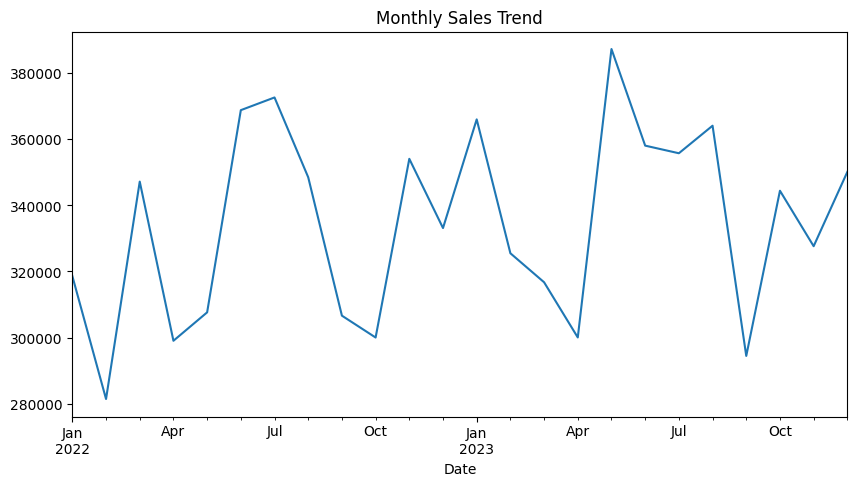

In [16]:
import matplotlib.pyplot as plt

monthly_sales.plot(figsize=(10,5))
plt.title("Monthly Sales Trend")
plt.show()

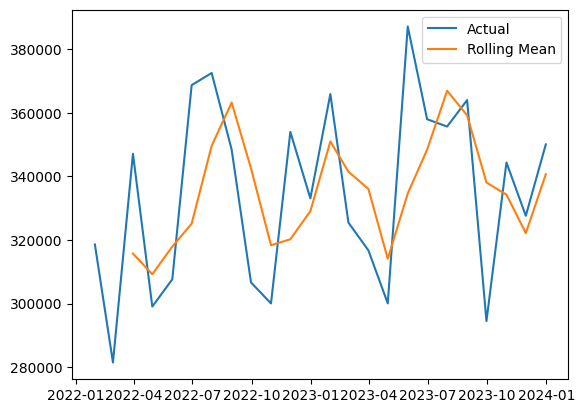

In [17]:
rolling = monthly_sales.rolling(window=3).mean()

plt.plot(monthly_sales, label="Actual")
plt.plot(rolling, label="Rolling Mean")
plt.legend()
plt.show()

In [18]:
train = monthly_sales[:'2023-06']
test = monthly_sales['2023-07':]

In [19]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

model = ExponentialSmoothing(train, trend="add")
fit = model.fit()

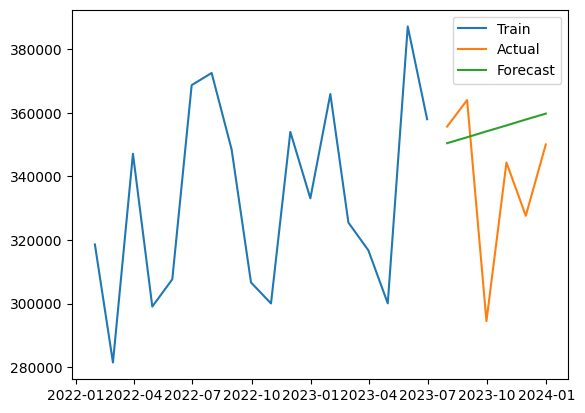

In [20]:
forecast = fit.forecast(len(test))

plt.plot(train, label="Train")
plt.plot(test, label="Actual")
plt.plot(forecast, label="Forecast")
plt.legend()
plt.show()

In [21]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(test, forecast)
print("MAE:", mae)

MAE: 21364.93696523193


In [22]:
mape = (abs((test - forecast)/test)).mean()*100
print("MAPE:", mape)

MAPE: 6.721611109397873


In [23]:
result = pd.DataFrame({
    "Actual": test,
    "Forecast": forecast
})

result.to_csv("walmart_forecast_results.csv")

**INSIGHTS**:-
Sales show stable growth across stores
Minor seasonal variation observed
Forecast predicts consistent demand